# Analyze GRPO Reward Learning

This notebook reads the GRPO trainer metrics log for a single run and plots the total reward and each reward component over optimization steps.

Primary target in this notebook:
- `experiments/checkpoints/grpo_in_memory_cancer_obs100_int10_anon_only_v2/grpo_log/train_metrics.jsonl`


In [15]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)


In [16]:
train_metrics_path = Path('/u/chenyuen0103/ENCO/experiments/checkpoints/grpo_in_memory_cancer_obs100_int10_anon_only_v2/grpo_log/train_metrics.jsonl')
assert train_metrics_path.exists(), train_metrics_path
train_metrics_path


PosixPath('/u/chenyuen0103/ENCO/experiments/checkpoints/grpo_in_memory_cancer_obs100_int10_anon_only_v2/grpo_log/train_metrics.jsonl')

In [17]:
df = pd.read_json(train_metrics_path, lines=True)

# Keep only per-step training rows; the final trainer summary row has runtime stats but no reward columns.
df = df[df['global_step'].notna()].copy()
df = df.sort_values('global_step').drop_duplicates(subset=['global_step'], keep='first').reset_index(drop=True)

reward_mean_cols = [c for c in df.columns if c.startswith('rewards/') and c.endswith('/mean')]
reward_std_cols = [c for c in df.columns if c.startswith('rewards/') and c.endswith('/std')]

print(f'rows: {len(df)}')
print('reward mean columns:')
for col in reward_mean_cols:
    print('  ', col)

df.head()


rows: 18
reward mean columns:
   rewards/cd_format_reward/mean
   rewards/cd_partial_format_reward/mean
   rewards/cd_edge_f1_reward/mean
   rewards/cd_low_shd_reward/mean
   rewards/cd_acyclic_reward/mean
   rewards/cd_graph_reward/mean


,global_step,epoch,time_unix,loss,grad_norm,learning_rate,num_tokens,completions/mean_length,completions/min_length,completions/max_length,completions/clipped_ratio,completions/mean_terminated_length,completions/min_terminated_length,completions/max_terminated_length,rewards/cd_format_reward/mean,rewards/cd_format_reward/std,rewards/cd_partial_format_reward/mean,rewards/cd_partial_format_reward/std,rewards/cd_edge_f1_reward/mean,rewards/cd_edge_f1_reward/std,rewards/cd_low_shd_reward/mean,rewards/cd_low_shd_reward/std,rewards/cd_acyclic_reward/mean,rewards/cd_acyclic_reward/std,rewards/cd_graph_reward/mean,rewards/cd_graph_reward/std,reward,reward_std,frac_reward_zero_std,kl,entropy,clip_ratio/low_mean,clip_ratio/low_min,clip_ratio/high_mean,clip_ratio/high_max,clip_ratio/region_mean,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,5,0.055556,1.775625e+09,0.0001,0.007355,0.000010,30720.0,1024.0,1024.0,1024.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000375,0.00075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000375,0.00075,0.8,0.003574,0.571118,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,10,0.111111,1.775625e+09,0.0001,0.006775,0.000009,61440.0,1024.0,1024.0,1024.0,1.0,0.0,0.0,0.0,0.0,0.0,0.001500,0.00300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001500,0.00300,0.6,0.005765,0.569900,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,15,0.166667,1.775626e+09,0.0001,0.245117,0.000008,92160.0,1024.0,1024.0,1024.0,1.0,0.0,0.0,0.0,0.0,0.0,0.001500,0.00300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001500,0.00300,0.4,0.002851,0.579111,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,20,0.222222,1.775626e+09,0.0001,0.002151,0.000008,122880.0,1024.0,1024.0,1024.0,1.0,0.0,0.0,0.0,0.0,0.0,0.001125,0.00225,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001125,0.00225,0.4,0.003420,0.570836,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,25,0.277778,1.775627e+09,0.0001,0.005920,0.000007,153600.0,1024.0,1024.0,1024.0,1.0,0.0,0.0,0.0,0.0,0.0,0.001125,0.00225,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.001125,0.00225,0.6,0.002852,0.537145,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [18]:
summary_cols = [
    'global_step',
    'epoch',
    'reward',
    'reward_std',
    'frac_reward_zero_std',
    'completions/clipped_ratio',
    'kl',
    'entropy',
] + reward_mean_cols

df[summary_cols]


,global_step,epoch,reward,reward_std,frac_reward_zero_std,completions/clipped_ratio,kl,entropy,rewards/cd_format_reward/mean,rewards/cd_partial_format_reward/mean,rewards/cd_edge_f1_reward/mean,rewards/cd_low_shd_reward/mean,rewards/cd_acyclic_reward/mean,rewards/cd_graph_reward/mean
0,5,0.055556,0.000375,0.000750,0.8,1.0,0.003574,0.571118,0.0,0.000375,0.000000,0.0000,0.0,0.000000
1,10,0.111111,0.001500,0.003000,0.6,1.0,0.005765,0.569900,0.0,0.001500,0.000000,0.0000,0.0,0.000000
2,15,0.166667,0.001500,0.003000,0.4,1.0,0.002851,0.579111,0.0,0.001500,0.000000,0.0000,0.0,0.000000
3,20,0.222222,0.001125,0.002250,0.4,1.0,0.003420,0.570836,0.0,0.001125,0.000000,0.0000,0.0,0.000000
4,25,0.277778,0.001125,0.002250,0.6,1.0,0.002852,0.537145,0.0,0.001125,0.000000,0.0000,0.0,0.000000
5,30,0.333333,0.001125,0.001436,0.8,1.0,0.003438,0.545232,0.0,0.001125,0.000000,0.0000,0.0,0.000000
6,35,0.388889,0.001500,0.002366,0.4,1.0,0.003893,0.694490,0.0,0.001500,0.000000,0.0000,0.0,0.000000
7,40,0.444444,0.001125,0.001616,0.6,1.0,0.003122,0.613125,0.0,0.001125,0.000000,0.0000,0.0,0.000000
8,45,0.500000,0.000375,0.000750,0.8,1.0,0.005810,0.592817,0.0,0.000375,0.000000,0.0000,0.0,0.000000
9,50,0.555556,0.041588,0.081189,0.4,1.0,0.003120,0.542765,0.0,0.003250,0.017647,0.0225,0.0,-0.001809


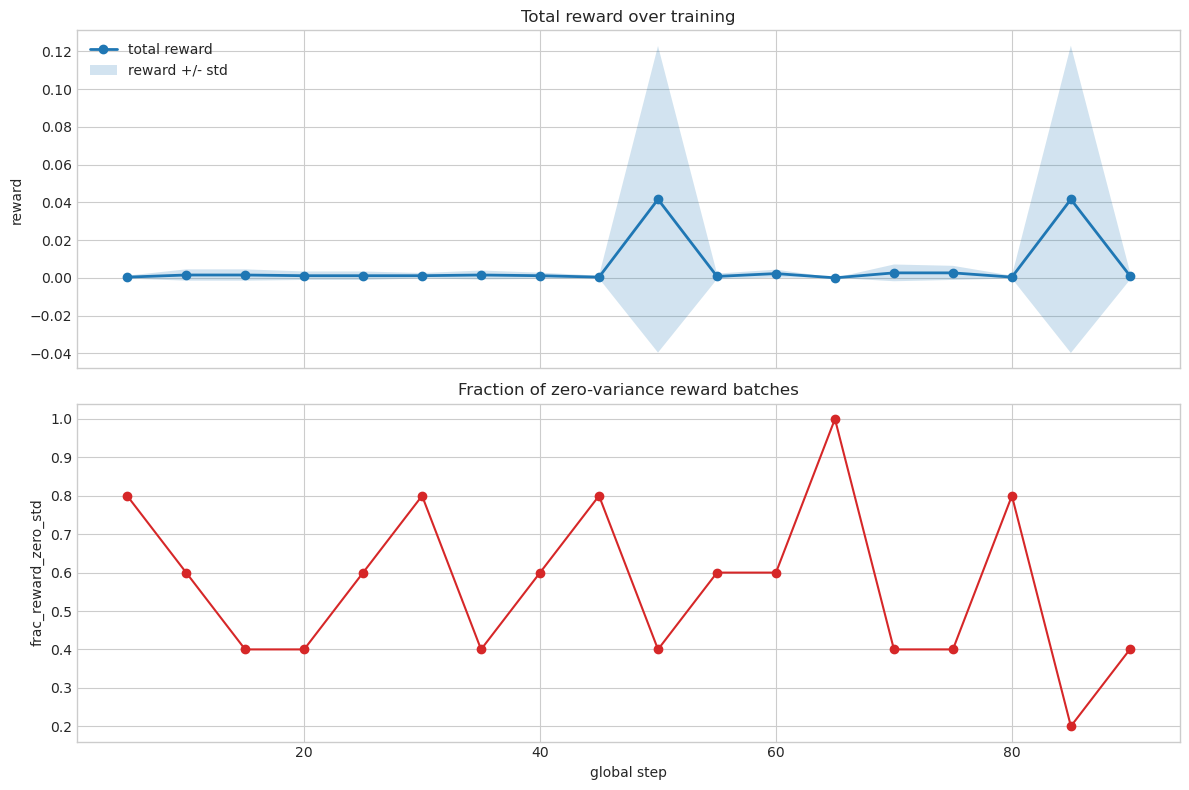

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(df['global_step'], df['reward'], marker='o', linewidth=2, label='total reward')
if 'reward_std' in df.columns:
    axes[0].fill_between(
        df['global_step'],
        df['reward'] - df['reward_std'],
        df['reward'] + df['reward_std'],
        alpha=0.2,
        label='reward +/- std',
    )
axes[0].set_ylabel('reward')
axes[0].set_title('Total reward over training')
axes[0].legend(loc='best')

axes[1].plot(df['global_step'], df['frac_reward_zero_std'], marker='o', color='tab:red')
axes[1].set_xlabel('global step')
axes[1].set_ylabel('frac_reward_zero_std')
axes[1].set_title('Fraction of zero-variance reward batches')

plt.tight_layout()


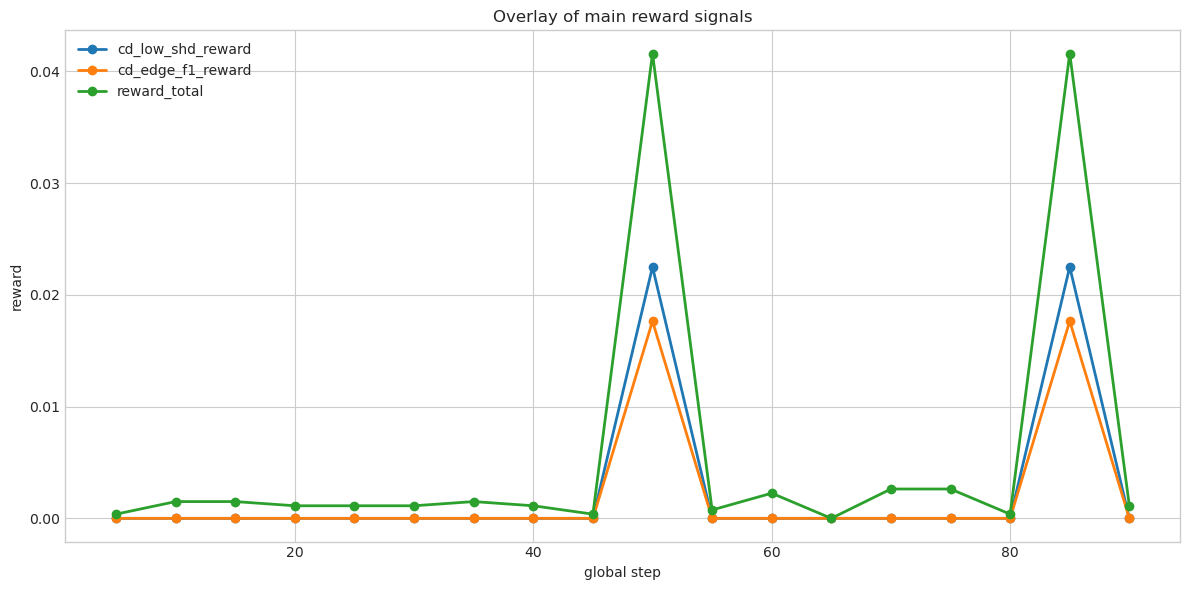

In [22]:
overlay_cols = [
    # 'rewards/cd_format_reward/mean',
    'rewards/cd_low_shd_reward/mean',
    'rewards/cd_edge_f1_reward/mean',
    'reward',
]
overlay_cols = [c for c in overlay_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(12, 6))
for col in overlay_cols:
    label = 'reward_total' if col == 'reward' else col.removeprefix('rewards/').removesuffix('/mean')
    ax.plot(df['global_step'], df[col], marker='o', linewidth=2, label=label)

ax.set_xlabel('global step')
ax.set_ylabel('reward')
ax.set_title('Overlay of main reward signals')
ax.legend(loc='best')
plt.tight_layout()


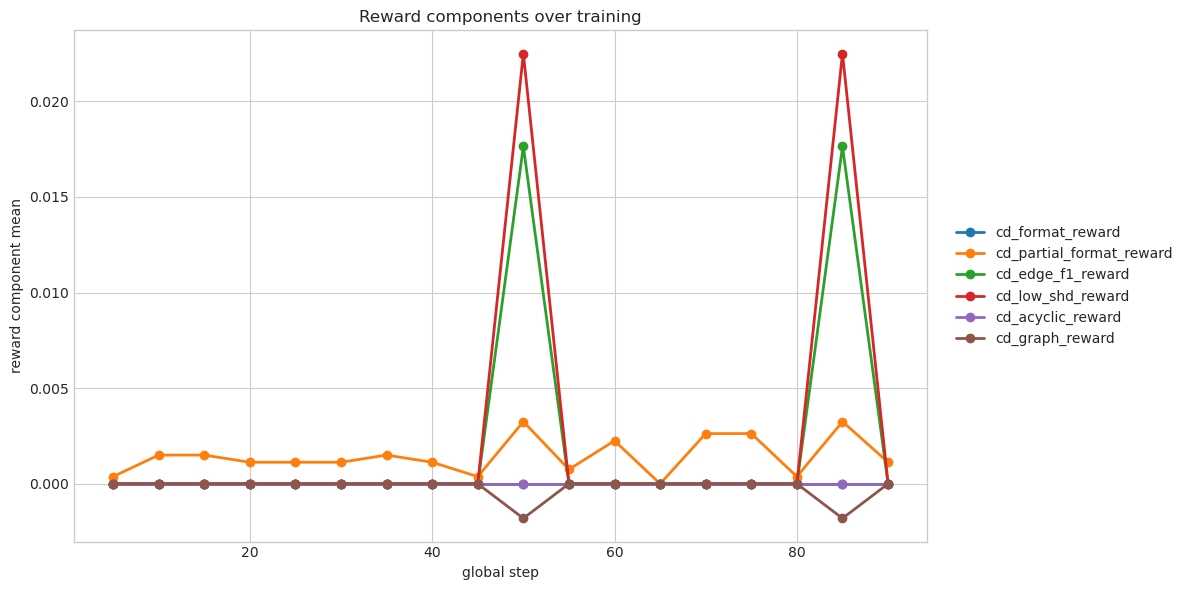

In [21]:
if reward_mean_cols:
    fig, ax = plt.subplots(figsize=(12, 6))
    for col in reward_mean_cols:
        short = col.removeprefix('rewards/').removesuffix('/mean')
        ax.plot(df['global_step'], df[col], marker='o', linewidth=2, label=short)
    ax.set_xlabel('global step')
    ax.set_ylabel('reward component mean')
    ax.set_title('Reward components over training')
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
else:
    print('No reward component mean columns found.')


In [7]:
positive_reward_cols = [col for col in reward_mean_cols if df[col].fillna(0).abs().max() > 0]
zero_reward_cols = [col for col in reward_mean_cols if col not in positive_reward_cols]

print('Reward components that moved:')
for col in positive_reward_cols:
    print('  ', col)

print('\nReward components that stayed at 0:')
for col in zero_reward_cols:
    print('  ', col)


Reward components that moved:
   rewards/cd_partial_format_reward/mean
   rewards/cd_edge_f1_reward/mean
   rewards/cd_low_shd_reward/mean
   rewards/cd_graph_reward/mean

Reward components that stayed at 0:
   rewards/cd_format_reward/mean
   rewards/cd_acyclic_reward/mean


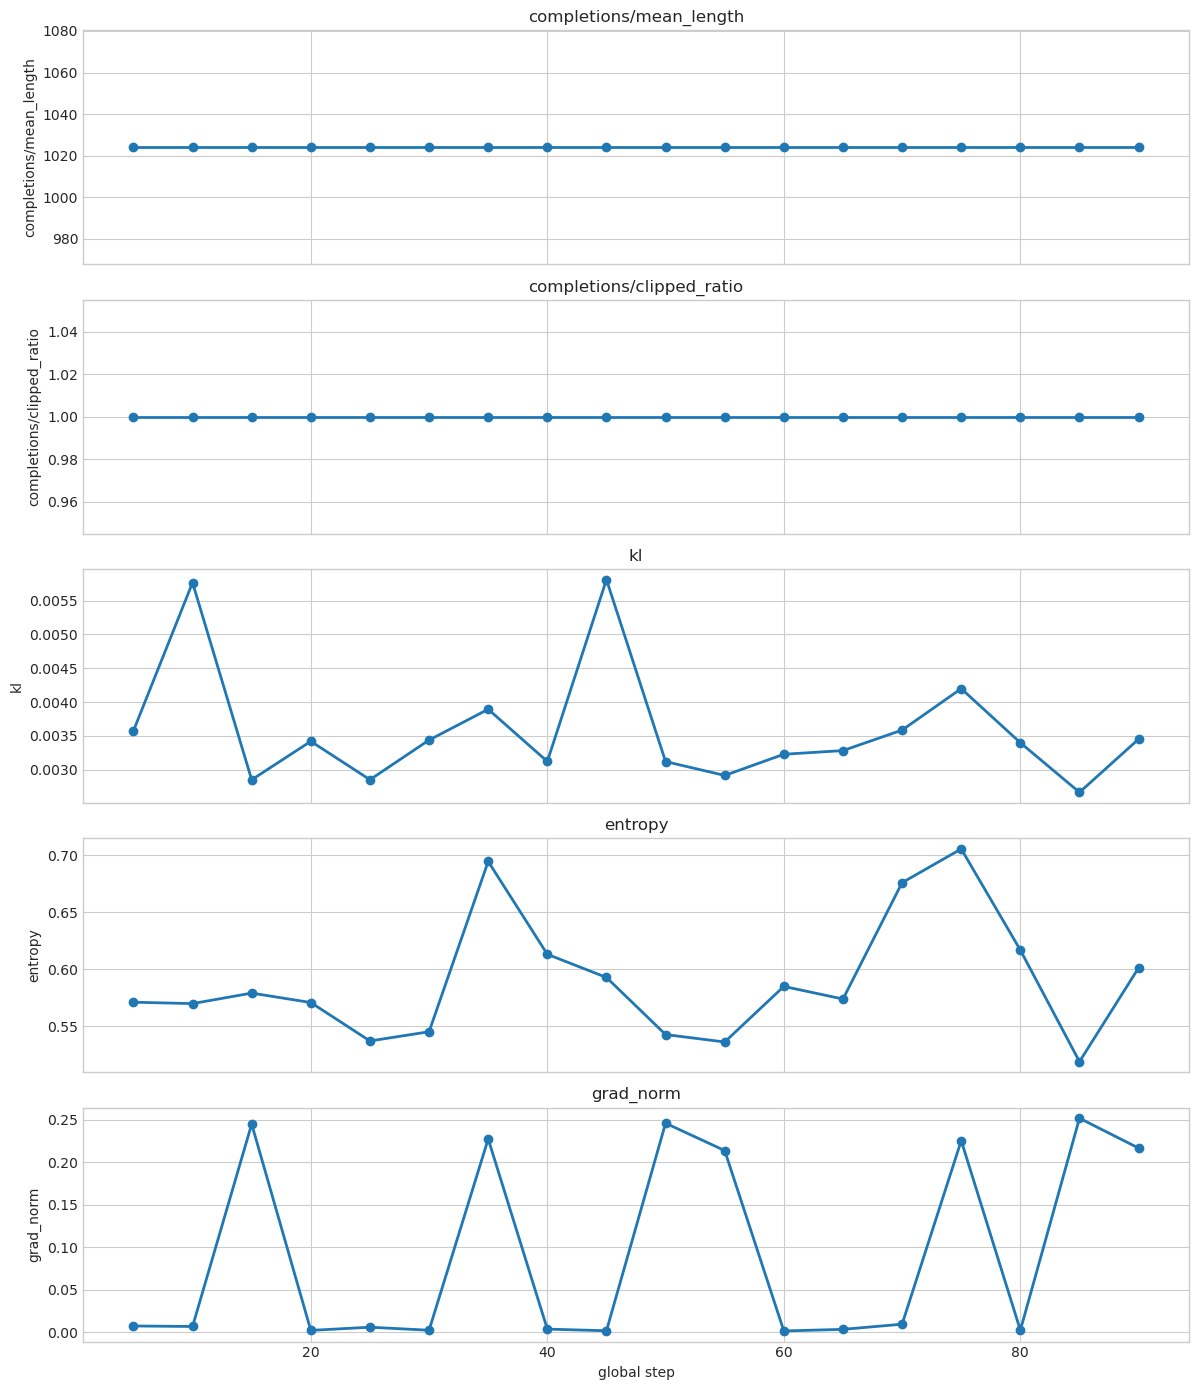

In [13]:
diagnostic_cols = [
    'completions/mean_length',
    'completions/clipped_ratio',
    'kl',
    'entropy',
    'grad_norm',
]

available_diagnostic_cols = [c for c in diagnostic_cols if c in df.columns]
n = len(available_diagnostic_cols)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.8 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, col in zip(axes, available_diagnostic_cols):
    ax.plot(df['global_step'], df[col], marker='o', linewidth=2)
    ax.set_ylabel(col)
    ax.set_title(col)

axes[-1].set_xlabel('global step')
plt.tight_layout()


In [14]:
display_cols = ['global_step', 'reward', 'reward_std', 'frac_reward_zero_std'] + positive_reward_cols
df[display_cols].describe().T


NameError: name 'positive_reward_cols' is not defined

In [35]:
import json
with open("/u/chenyuen0103/ENCO/experiments/data/small_mixed_staged_sft.jsonl", "r") as f:
    data = [json.loads(line) for line in f]


In [36]:
print(data[0]['prompt'])

system
A conversation between User and Assistant. The user asks a question, and the Assistant solves it. The assistant reasons step by step inside <think> tags, following three explicit stages:
  Stage 1 (Skeleton): List each directly connected variable pair on its own line as "X -- Y". If none, write "None".
  Stage 2 (V-structures): List each unshielded collider as "(parent1, collider, parent2)" on its own line. If none, write "None".
  Stage 3 (Orientation): List each directed edge on its own line as "X -> Y". If none, write "None".
After reasoning, the assistant outputs the final adjacency matrix inside <answer> tags.
user
You are a question-answering assistant with knowledge of causal inference and causal discovery.
The following are empirical distributions computed from data sampled from an anonymized Bayesian network.
Infer the directed causal graph over the variables.

--- VARIABLES ---
0: X1
1: X2
2: X3
3: X4
4: X5

--- DATA FORMAT ---
num_states=[2,2,2,2,2]. hist entries: [as

In [34]:
print(data[0]['answer'])

Stage 1 (Skeleton):
X1 -- X5
X2 -- X5
X3 -- X5
X4 -- X5

Stage 2 (V-structures):
(X2, X5, X4)

Stage 3 (Orientation):
X2 -> X5
X4 -> X5
X5 -> X1
X5 -> X3</think><answer>{"adjacency_matrix": [[0, 0, 0, 0, 0], [0, 0, 0, 0, 1], [0, 0, 0, 0, 0], [0, 0, 0, 0, 1], [1, 0, 1, 0, 0]]}</answer>
